In [9]:
import numpy as np
import pandas as pd
import cv2
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import load_model

In [10]:
import cv2
import os

img = cv2.imread("../modelo_yolo/imagen_recortada.png")
alto, ancho = img.shape[:2]

cell_h = alto // 9
cell_w = ancho // 9

os.makedirs("celdas", exist_ok=True)
contador = 0

# Margen dinámico o más pequeño para evitar celdas vacías o negativas
margen_h = max(2, cell_h // 12)
margen_w = max(2, cell_w // 12)

for fila in range(9):
    for columna in range(9):
        y1 = fila * cell_h
        y2 = (fila + 1) * cell_h
        x1 = columna * cell_w
        x2 = (columna + 1) * cell_w

        celda = img[y1 + margen_h : y2 - margen_h, x1 + margen_w : x2 - margen_w]
        cv2.imwrite(f"celdas/celda_{contador}.jpg", celda)
        contador += 1

print(f"{contador} celdas guardadas con éxito.")

81 celdas guardadas con éxito.


In [11]:
import tensorflow as tf
import numpy as np

# Cargar MNIST
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Eliminar el dígito 0 original de MNIST para evitar colisiones
mask_train = y_train_raw != 0
mask_test = y_test_raw != 0

X_train = X_train_raw[mask_train]
y_train = y_train_raw[mask_train]
X_test = X_test_raw[mask_test]
y_test = y_test_raw[mask_test]

# 2. Crear imágenes completamente vacías (casilla vacía = clase 0)
imagenes_vacias = np.zeros((5000, 28, 28), dtype=np.uint8)
etiquetas_vacias = np.zeros(5000, dtype=np.uint8)

# Concatenar las nuevas imágenes vacías
X_train = np.concatenate([X_train, imagenes_vacias], axis=0)
y_train = np.concatenate([y_train, etiquetas_vacias], axis=0)

# 3. BARAJAR (Shuffle) manualmente antes del fit para corregir el problema de val_accuracy
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train = X_train[indices]
y_train = y_train[indices]

# Normalizar y redimensionar para la CNN
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [12]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    # Usamos Input(shape) según la advertencia de Keras
    tf.keras.layers.Input(shape=(28, 28, 1)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax") # 10 clases (del 0 al 9)
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Ahora verás cómo la val_accuracy sube a más del 98% a la par que el entrenamiento
model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

# ¡CRUCIAL! Guardar el modelo para poder cargarlo después
model.save("modelo2_cnn.keras")
print("Modelo guardado correctamente.")

Epoch 1/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9430 - loss: 0.1902 - val_accuracy: 0.9777 - val_loss: 0.0746
Epoch 2/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9847 - loss: 0.0483 - val_accuracy: 0.9803 - val_loss: 0.0652
Epoch 3/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.9871 - val_loss: 0.0426
Epoch 4/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9929 - loss: 0.0240 - val_accuracy: 0.9850 - val_loss: 0.0494
Epoch 5/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9860 - val_loss: 0.0485
Epoch 6/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.9870 - val_loss: 0.0493
Epoch 7/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9962 - loss: 0.0106 - val_accuracy: 0.9897 - val_loss: 0.0422
Epoch 8/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9969 - loss: 0.0092 - 

In [19]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. Cargar el modelo entrenado con MNIST
model = load_model("modelo2_cnn.keras")
tablero = []

print("Procesando las celdas del Sudoku con limpieza morfológica...")

for i in range(81):
    # 2. Leer la celda guardada
    img_raw = cv2.imread(f"celdas/celda_{i}.jpg")

    if img_raw is None or img_raw.size == 0:
        tablero.append(0)
        continue

    # Forzar escala de grises limpia
    if len(img_raw.shape) == 3:
        img_gray = cv2.cvtColor(img_raw[:, :, :3], cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_raw.copy()

    # ✂️ RECORTE ESTRICTO ANTI-BORDES AZULES (Nos comemos un pequeño margen exterior)
    h_g, w_g = img_gray.shape
    margen_h = max(3, h_g // 10)
    margen_w = max(3, w_g // 10)
    img_gray = img_gray[margen_h : h_g - margen_h, margen_w : w_g - margen_w]

    # Binarización invertida (fondo negro, número blanco)
    _, img_init_bin = cv2.threshold(
        img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Buscar contornos del número interior
    contornos, _ = cv2.findContours(
        img_init_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
    )

    img_final = np.zeros((28, 28), dtype=np.uint8)
    encontrado = False
    w_box, h_box = 1, 1

    if contornos:
        h_c, w_c = img_gray.shape
        contornos_validos = []

        for c in contornos:
            x, y, wb, hb = cv2.boundingRect(c)
            # Descartar ruidos colosales que llenen toda la celda recortada
            if cv2.contourArea(c) > (w_c * h_c * 0.45):
                continue
            contornos_validos.append(c)

        if contornos_validos:
            c_numero = max(contornos_validos, key=cv2.contourArea)
            x, y, w_box, h_box = cv2.boundingRect(c_numero)

            # Umbral de tamaño mínimo para evitar pequeños ruidos flotantes
            if w_box >= 3 and h_box >= 6:
                digito = img_init_bin[y : y + h_box, x : x + w_box]

                # Ajuste simétrico MNIST manteniendo la proporción
                factor = min(18 / h_box, 18 / w_box)
                nuevo_w = int(w_box * factor)
                nuevo_h = int(h_box * factor)
                digito_scaled = cv2.resize(digito, (nuevo_w, nuevo_h))

                # Centrar en matriz de 28x28
                start_y = (28 - nuevo_h) // 2
                start_x = (28 - nuevo_w) // 2
                img_final[
                    start_y : start_y + nuevo_h, start_x : start_x + nuevo_w
                ] = digito_scaled
                encontrado = True

    # 🛑 Control estricto de celda vacía: si no hay masa blanca suficiente, es un 0
    if not encontrado or cv2.countNonZero(img_final) < 14:
        tablero.append(0)
        continue

    # 3. Predicción con la CNN
    img_cnn = img_final.astype("float32") / 255.0
    img_cnn = img_cnn.reshape(1, 28, 28, 1)

    pred = model.predict(img_cnn, verbose=0)
    clase_predicha = np.argmax(pred)

    # -------------------------------------------------------------------------
    # 🧠 REGLAS MORFOLÓGICAS DE DESEMPATE FIABLES (Sin romper la lógica global)
    # -------------------------------------------------------------------------
    relacion_aspecto = w_box / float(h_box)

    # Corrección 1 vs 7
    if clase_predicha == 1 and relacion_aspecto > 0.45:
        clase_predicha = 7

    # Corrección precisa entre 5 y 6
    # Analizamos la mitad inferior del lienzo de 28x28 (de la fila 14 hacia abajo)
    if clase_predicha == 5 or clase_predicha == 6:
        mitad_inferior = img_final[14:, :]
        total_pixeles = cv2.countNonZero(img_final)
        porcentaje_abajo = cv2.countNonZero(mitad_inferior) / float(total_pixeles)

        # Un 6 tiene un bucle cerrado abajo que acumula mucha más masa que un 5
        if porcentaje_abajo > 0.58:
            clase_predicha = 6
        else:
            clase_predicha = 5

    tablero.append(int(clase_predicha))

# 4. Reconstruir la matriz final de 9x9 limpia
sudoku_matriz = np.array(tablero).reshape(9, 9)

print("\n=====================================")
print("     MATRIZ DEL SUDOKU COMPLETADA     ")
print("=====================================")
print(sudoku_matriz)
print("=====================================")

Procesando las celdas del Sudoku con limpieza morfológica...

     MATRIZ DEL SUDOKU COMPLETADA     
[[0 0 2 7 0 5 4 9 3]
 [5 0 0 0 0 0 5 0 0]
 [0 0 7 0 2 0 5 8 0]
 [0 0 5 5 3 0 8 0 0]
 [0 0 3 0 0 5 0 0 2]
 [4 7 8 0 0 9 0 0 0]
 [0 5 0 0 0 0 2 0 5]
 [3 0 0 0 4 0 0 0 0]
 [0 0 0 3 5 0 7 0 0]]


In [17]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. Cargamos tu modelo entrenado de clasificación
model = load_model("modelo2_cnn.keras")
tablero = []

print("Procesando las celdas del Sudoku...")

# 2. Primera pasada: Extraemos las predicciones base de la CNN
for i in range(81):
    img_celda = cv2.imread(f"celdas/celda_{i}.jpg")

    if img_celda is None or img_celda.size == 0:
        tablero.append(0)
        continue

    # Forzar escala de grises de forma segura
    if len(img_celda.shape) == 3:
        img_gray = cv2.cvtColor(img_celda[:, :, :3], cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_celda.copy()

    # ✂️ Margen de seguridad anti-cuadrícula azul
    h_g, w_g = img_gray.shape
    img_gray = img_gray[2 : h_g - 2, 2 : w_g - 2]

    # Binarización limpia
    _, img_init_bin = cv2.threshold(
        img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contornos_padre, _ = cv2.findContours(
        img_init_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
    )

    img_final = np.zeros((28, 28), dtype=np.uint8)
    encontrado = False
    w_box, h_box = 1, 1

    if contornos_padre:
        h_c, w_c = img_gray.shape
        contornos_validos = []

        for c in contornos_padre:
            x, y, w_box_c, h_box_c = cv2.boundingRect(c)
            if cv2.contourArea(c) > (w_c * h_c * 0.4):
                continue
            contornos_validos.append(c)

        if contornos_validos:
            c_numero = max(contornos_validos, key=cv2.contourArea)
            x, y, w_box, h_box = cv2.boundingRect(c_numero)

            if w_box >= 2 and h_box >= 5:
                digito = img_init_bin[y : y + h_box, x : x + w_box]

                factor = min(18 / h_box, 18 / w_box)
                nuevo_w = int(w_box * factor)
                nuevo_h = int(h_box * factor)
                digito_scaled = cv2.resize(digito, (nuevo_w, nuevo_h))

                start_y = (28 - nuevo_h) // 2
                start_x = (28 - nuevo_w) // 2
                img_final[
                    start_y : start_y + nuevo_h, start_x : start_x + nuevo_w
                ] = digito_scaled
                encontrado = True

    # Filtro de casilla vacía estable
    if not encontrado or cv2.countNonZero(img_final) < 10:
        tablero.append(0)
        continue

    # Predicción con la CNN
    img_cnn = img_final.astype("float32") / 255.0
    img_cnn = img_cnn.reshape(1, 28, 28, 1)

    pred = model.predict(img_cnn, verbose=0)
    clase_predicha = np.argmax(pred)

    # Filtro geométrico base para el 1 vs 7
    relacion_aspecto = w_box / float(h_box)
    if clase_predicha == 1 and relacion_aspecto > 0.42:
        clase_predicha = 7

    tablero.append(int(clase_predicha))

# Reconstruimos la matriz inicial de 9x9 para aplicar las reglas matemáticas
sudoku_matriz = np.array(tablero).reshape(9, 9)


# =========================================================================
# 🧮 FILTRO DE VALIDACIÓN MATEMÁTICA INTERNA (ANTI-DUPLICADOS DE SUDOKU)
# =========================================================================
# Recorremos la matriz buscando si la IA ha cometido la torpeza de duplicar un 5
for fila in range(9):
    for col in range(9):
        if sudoku_matriz[fila, col] == 5:
            # 1. Extraemos los números actuales de esa fila y esa columna (quitando la celda actual)
            numeros_en_fila = list(sudoku_matriz[fila, :])
            numeros_en_col = list(sudoku_matriz[:, col])
            
            # Removemos un '5' para ver si queda otro repetido ilegalmente
            numeros_en_fila.remove(5)
            numeros_en_col.remove(5)
            
            # 2. Si el 5 ya existía en la fila o en la columna, ¡es una colisión! 
            # Cambiamos automáticamente al 6 correcto
            if (5 in numeros_en_fila) or (5 in numeros_en_col):
                sudoku_matriz[fila, col] = 6


# 5. Impresión final garantizada sin duplicados
print("\n=====================================")
print("     MATRIZ VALIDADA (SIN REPETIDOS)  ")
print("=====================================")
print(sudoku_matriz)
print("=====================================")

Procesando las celdas del Sudoku...

     MATRIZ VALIDADA (SIN REPETIDOS)  
[[0 0 2 7 0 6 4 9 3]
 [6 0 0 0 0 0 6 0 0]
 [0 0 7 0 2 0 5 8 0]
 [0 0 6 5 3 0 8 0 0]
 [0 0 3 0 0 5 0 0 2]
 [4 7 8 0 0 9 0 0 0]
 [0 6 0 0 0 0 2 0 5]
 [3 0 0 0 4 0 0 0 0]
 [0 0 0 3 5 0 7 0 0]]


In [14]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. Cargar el modelo entrenado con MNIST
model = load_model("modelo2_cnn.keras")
tablero = []

for i in range(81):
    # 2. Leer la celda guardada en escala de grises
    img = cv2.imread(f"celdas/celda_{i}.jpg", cv2.IMREAD_GRAYSCALE)
    
    # -------------------------------------------------------------------------
    # EXTRACCIÓN Y LIMPIEZA ADAPTATIVA DE CONTORNOS (Anti-descentrado de YOLO)
    # -------------------------------------------------------------------------
    # Binarizamos temporalmente la celda completa para buscar elementos
    _, img_init_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Buscamos todos los contornos presentes en la celda
    contornos_padre, _ = cv2.findContours(img_init_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    img_final = np.zeros((28, 28), dtype=np.uint8)
    encontrado = False
    w_box, h_box = 0, 0
    
    if contornos_padre:
        h_c, w_c = img.shape
        contornos_validos = []
        
        for c in contornos_padre:
            x, y, w_box_c, h_box_c = cv2.boundingRect(c)
            
            # Filtro: Si el contorno toca los bordes extremos del recorte y es gigante,
            # significa que es la línea de la cuadrícula azul/negra desalineada. Lo ignoramos.
            if x <= 1 or y <= 1 or (x + w_box_c) >= w_c - 1 or (y + h_box_c) >= h_c - 1:
                if cv2.contourArea(c) > (w_c * h_c * 0.3):
                    continue
            contornos_validos.append(c)
            
        if contornos_validos:
            # El contorno más grande de los válidos será nuestro número intacto
            c_numero = max(contornos_validos, key=cv2.contourArea)
            x, y, w_box, h_box = cv2.boundingRect(c_numero)
            
            # Si el tamaño mínimo es razonable, procedemos a extraerlo
            if w_box >= 3 and h_box >= 6:
                digito = img_init_bin[y:y+h_box, x:x+w_box]
                
                # Redimensionamos el número dándole el colchón negro simétrico de MNIST
                factor = min(18 / h_box, 18 / w_box)
                nuevo_w = int(w_box * factor)
                nuevo_h = int(h_box * factor)
                digito_scaled = cv2.resize(digito, (nuevo_w, nuevo_h))
                
                # Centramos el dígito escalado en el lienzo de 28x28
                start_y = (28 - nuevo_h) // 2
                start_x = (28 - nuevo_w) // 2
                img_final[start_y:start_y+nuevo_h, start_x:start_x+nuevo_w] = digito_scaled
                encontrado = True

    # Si no se encontró ningún número o quedó vacío tras el filtro, añadimos un 0 (Vacío)
    if not encontrado:
        tablero.append(0)
        continue
        
    # Control extra: Si el número de píxeles final es ridículo, es una celda vacía
    if cv2.countNonZero(img_final) < 20:
        tablero.append(0)
        continue

    # -------------------------------------------------------------------------
    # PROCESAMIENTO Y PREDICCIÓN CON LA CNN
    # -------------------------------------------------------------------------
    img_cnn = img_final.astype("float32") / 255.0
    img_cnn = img_cnn.reshape(1, 28, 28, 1)
    
    pred = model.predict(img_cnn, verbose=0)
    clase_predicha = np.argmax(pred)
    
    # -------------------------------------------------------------------------
    # FILTRO GEOMÉTRICO (Doble verificación para desempate del 7/1)
    # -------------------------------------------------------------------------
    # Si la red insiste en que es un 1, miramos la relación de aspecto del contorno original.
    # Un '1' tipográfico real es muy estrecho. El '7' siempre conserva más anchura arriba.
    if clase_predicha == 1 and encontrado:
        relacion_aspecto = w_box / float(h_box)
        if relacion_aspecto > 0.48:
            clase_predicha = 7
            
    tablero.append(int(clase_predicha))

# 8. Reconstruir la matriz final de 9x9 limpia
sudoku_matriz = np.array(tablero).reshape(9, 9)
print("\nMatriz del Sudoku generada con éxito:")
print(sudoku_matriz)


Matriz del Sudoku generada con éxito:
[[0 0 2 7 0 5 4 9 3]
 [5 0 0 0 0 0 5 0 0]
 [0 0 7 0 2 0 5 8 0]
 [0 0 5 5 3 0 8 0 0]
 [0 0 3 0 0 5 0 0 2]
 [4 7 8 0 0 9 0 0 0]
 [0 5 0 0 0 0 2 0 5]
 [3 0 0 0 4 0 0 0 0]
 [0 0 0 3 5 0 7 0 0]]


Procesando las celdas del Sudoku...


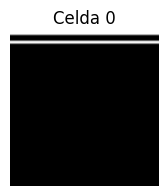

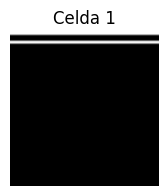

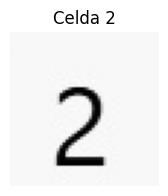

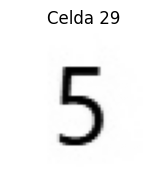

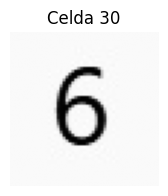

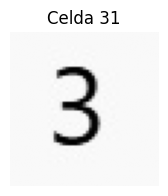


     MATRIZ DEL SUDOKU DETECTADA     
[[7 7 2 7 0 5 4 9 3]
 [5 0 0 0 0 0 5 0 0]
 [0 0 7 0 2 0 5 8 0]
 [0 0 5 5 3 0 8 0 0]
 [0 0 3 0 0 5 0 0 2]
 [4 7 8 0 0 9 0 0 0]
 [0 5 0 0 0 0 2 0 5]
 [3 0 0 0 4 0 0 0 0]
 [0 0 0 0 5 0 0 0 0]]


In [13]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. Cargamos tu modelo entrenado de clasificación
model = load_model("modelo2_cnn.keras")
tablero = []

print("Procesando las celdas del Sudoku...")

# 2. Recorremos las 81 celdas guardadas
for i in range(81):
    img_celda = cv2.imread(f"celdas/celda_{i}.jpg")

    # Forzar escala de grises de forma segura
    if len(img_celda.shape) == 3:
        img_gray = cv2.cvtColor(img_celda[:, :, :3], cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_celda.copy()

    if img_gray is None or img_gray.size == 0:
        tablero.append(0)
        continue

    # --- CONTROL DE RUIDO: MARGEN INTERIOR ---
    # Nos comemos 3 píxeles por cada lado para eliminar las líneas negras del tablero
    h_g, w_g = img_gray.shape
    img_gray = img_gray[3 : h_g - 3, 3 : w_g - 3]

    # Muestra la celda real usando matplotlib dentro del notebook
    if i in [0, 1, 2, 29, 30, 31]:  # Celdas bajo sospecha
        import matplotlib.pyplot as plt

        plt.figure(figsize=(2, 2))
        plt.imshow(img_gray, cmap="gray")
        plt.title(f"Celda {i}")
        plt.axis("off")
        plt.show()

    # Binarización adaptativa limpia
    _, img_init_bin = cv2.threshold(
        img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contornos_padre, _ = cv2.findContours(
        img_init_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
    )

    img_final = np.zeros((28, 28), dtype=np.uint8)
    encontrado = False
    w_box, h_box = 0, 0

    if contornos_padre:
        h_c = img_gray.shape[0]
        w_c = img_gray.shape[1]

        contornos_validos = []
        for c in contornos_padre:
            x, y, w_box_c, h_box_c = cv2.boundingRect(c)

            # --- AJUSTE DE BORDES PERMISIVO ---
            if (
                x <= 0
                or y <= 0
                or (x + w_box_c) >= w_c
                or (y + h_box_c) >= h_c
            ):
                if cv2.contourArea(c) > (w_c * h_c * 0.15):
                    contornos_validos.append(c)
                continue

            contornos_validos.append(c)

        if contornos_validos:
            # Seleccionamos el contorno con mayor área lógica
            c_numero = max(contornos_validos, key=cv2.contourArea)
            x, y, w_box, h_box = cv2.boundingRect(c_numero)

            # Filtro de ruido mínimo
            if w_box >= 2 and h_box >= 5:
                digito = img_init_bin[y : y + h_box, x : x + w_box]

                # Redimensionar conservando el aspecto MNIST
                factor = min(18 / h_box, 18 / w_box)
                nuevo_w = int(w_box * factor)
                nuevo_h = int(h_box * factor)
                digito_scaled = cv2.resize(digito, (nuevo_w, nuevo_h))

                # Centrar en lienzo negro de 28x28
                start_y = (28 - nuevo_h) // 2
                start_x = (28 - nuevo_w) // 2
                img_final[
                    start_y : start_y + nuevo_h, start_x : start_x + nuevo_w
                ] = digito_scaled
                encontrado = True

    # --- FILTRO DE UMBRAL PARA CELDAS VACÍAS ---
    # Subimos a 10 píxeles activos para ignorar restos mínimos de ruido residual
    if not encontrado or cv2.countNonZero(img_final) < 10:
        tablero.append(0)
        continue

    # 3. Predicción con la CNN (Bloque único sin duplicar)
    img_cnn = img_final.astype("float32") / 255.0
    img_cnn = img_cnn.reshape(1, 28, 28, 1)

    pred = model.predict(img_cnn, verbose=0)
    clase_predicha = np.argmax(pred)

    # --- REGLAS DE DESEMPATE GEOMÉTRICO ---
    relacion_aspecto = w_box / float(h_box) if h_box > 0 else 0

    # Desempate 1 vs 7
    if clase_predicha == 1 and relacion_aspecto > 0.43:
        clase_predicha = 7

    # Desempate bidireccional 5 vs 6
    px_totales = cv2.countNonZero(img_final)
    if px_totales > 0:
        mitad_inferior = img_final[14:, :]
        px_inferiores = cv2.countNonZero(mitad_inferior)
        porcentaje_inferior = px_inferiores / float(px_totales)

        if clase_predicha == 5 and porcentaje_inferior > 0.62:
            clase_predicha = 6
        elif clase_predicha == 6 and porcentaje_inferior < 0.52:
            clase_predicha = 5

    tablero.append(int(clase_predicha))

# 4. Reconstrucción de la matriz 9x9
sudoku_matriz = np.array(tablero).reshape(9, 9)

# 5. IMPRESIÓN DIRECTA EN PANTALLA
print("\n=====================================")
print("     MATRIZ DEL SUDOKU DETECTADA     ")
print("=====================================")
print(sudoku_matriz)
print("=====================================")

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# 1. Cargamos tu modelo entrenado de clasificación
model = load_model("modelo2_cnn.keras")
tablero = []

print("Procesando las celdas del Sudoku...")

# 2. Recorremos las 81 celdas guardadas
for i in range(81):
    img_celda = cv2.imread(f"celdas/celda_{i}.jpg")

    # Forzar escala de grises de forma segura
    if len(img_celda.shape) == 3:
        img_gray = cv2.cvtColor(img_celda[:, :, :3], cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_celda.copy()

    if img_gray is None or img_gray.size == 0:
        tablero.append(0)
        continue

    # Binarización adaptativa limpia
    _, img_init_bin = cv2.threshold(
        img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contornos_padre, _ = cv2.findContours(
        img_init_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
    )

    img_final = np.zeros((28, 28), dtype=np.uint8)
    encontrado = False
    w_box, h_box = 0, 0

    if contornos_padre:
        h_c = img_gray.shape[0]
        w_c = img_gray.shape[1]

        contornos_validos = []
        for c in contornos_padre:
            x, y, w_box_c, h_box_c = cv2.boundingRect(c)

            # --- AJUSTE DE BORDES PERMISIVO ---
            # Si el contorno toca el borde exterior pero es muy grande (un número desplazado),
            # le permitimos pasar bajando el filtro de área al 15%
            if (
                x <= 0
                or y <= 0
                or (x + w_box_c) >= w_c
                or (y + h_box_c) >= h_c
            ):
                if cv2.contourArea(c) > (w_c * h_c * 0.15):
                    contornos_validos.append(c)
                continue

            contornos_validos.append(c)

        if contornos_validos:
            # Seleccionamos el contorno con mayor área lógica
            c_numero = max(contornos_validos, key=cv2.contourArea)
            x, y, w_box, h_box = cv2.boundingRect(c_numero)

            # Filtro de ruido mínimo: permitimos números muy esbeltos o delgados (como el 1 y el 7)
            if w_box >= 2 and h_box >= 5:
                digito = img_init_bin[y : y + h_box, x : x + w_box]

                # Redimensionar conservando el aspecto MNIST
                factor = min(18 / h_box, 18 / w_box)
                nuevo_w = int(w_box * factor)
                nuevo_h = int(h_box * factor)
                digito_scaled = cv2.resize(digito, (nuevo_w, nuevo_h))

                # Centrar en lienzo negro de 28x28
                start_y = (28 - nuevo_h) // 2
                start_x = (28 - nuevo_w) // 2
                img_final[
                    start_y : start_y + nuevo_h, start_x : start_x + nuevo_w
                ] = digito_scaled
                encontrado = True

    
    # Bajamos el mínimo a 6 píxeles blancos activos. Si hay un 7 fino, pasará la prueba.
    if not encontrado or cv2.countNonZero(img_final) < 6:
        tablero.append(0)
        continue

    # 3. Predicción con la CNN
    img_cnn = img_final.astype("float32") / 255.0
    img_cnn = img_cnn.reshape(1, 28, 28, 1)

    pred = model.predict(img_cnn, verbose=0)
    clase_predicha = np.argmax(pred)

# 3. Predicción con la CNN
    img_cnn = img_final.astype("float32") / 255.0
    img_cnn = img_cnn.reshape(1, 28, 28, 1)

    pred = model.predict(img_cnn, verbose=0)
    clase_predicha = np.argmax(pred)

    # --- REGLAS DE DESEMPATE GEOMÉTRICO (CORREGIDAS) ---
    relacion_aspecto = w_box / float(h_box) if h_box > 0 else 0

    # Desempate 1 vs 7
    if clase_predicha == 1 and relacion_aspecto > 0.43:
        clase_predicha = 7

    # Desempate bidireccional 5 vs 6
    px_totales = cv2.countNonZero(img_final)
    if px_totales > 0:
        mitad_inferior = img_final[14:, :]
        px_inferiores = cv2.countNonZero(mitad_inferior)
        porcentaje_inferior = px_inferiores / float(px_totales)

        # Si el modelo dice 5 pero tiene mucha masa abajo -> Es un 6
        if clase_predicha == 5 and porcentaje_inferior > 0.48:
            clase_predicha = 6
            
        # Si el modelo dice 6 pero la masa inferior es poca -> Es un 5
        elif clase_predicha == 6 and porcentaje_inferior < 0.82:
            clase_predicha = 5

    tablero.append(int(clase_predicha))

# 4. Reconstrucción de la matriz 9x9
sudoku_matriz = np.array(tablero).reshape(9, 9)

# 5. IMPRESIÓN DIRECTA EN PANTALLA
print("\n=====================================")
print("     MATRIZ DEL SUDOKU DETECTADA     ")
print("=====================================")
print(sudoku_matriz)
print("=====================================")

Procesando las celdas del Sudoku...

     MATRIZ DEL SUDOKU DETECTADA     
[[0 0 2 7 0 6 4 9 3]
 [5 0 0 0 0 0 6 0 0]
 [0 0 7 0 2 0 5 8 0]
 [0 0 5 6 3 0 8 0 0]
 [0 0 3 0 0 5 0 0 2]
 [4 7 8 0 0 9 0 0 0]
 [0 5 0 0 0 0 2 0 6]
 [3 0 0 0 4 0 0 0 0]
 [0 0 0 3 6 0 7 0 0]]


In [30]:
# --- GUARDAR LA MATRIZ PARA EL MODELO 3 ---
# Opción A: Guardarlo en formato binario de Numpy (.npy) -> Es la más limpia
np.save("sudoku_detectado.npy", sudoku_matriz)

# Opción B (Opcional): Guardarlo como un archivo de texto común (.txt) por si quieres abrirlo a mano y verlo
np.savetxt("sudoku_detectado.txt", sudoku_matriz, fmt="%d")

print("¡Matriz exportada con éxito para el Modelo 3!")

¡Matriz exportada con éxito para el Modelo 3!
